# Logical Relationship Testing

Testing logical relationships within a structure set.


## Logical Relationships

Within a set of structures, transitive relationships can result in **Logical** 
relationships, which exists out of necessity due to other relationships in the 
structure set. The simplest example is one where **A** *Contains* **B** and 
**B** *Contains* **C**, therefore the relationship **A** *Contains* **C** is **Logical** 
since it is a requirement of the other two relationships.  

**Logical** relationships can also be chained further. For example, 
if **C** *Contains* **D**, the relationships **A** *Contains* **D** and 
**B** *Contains* **D** are both **Logical**.


### Implied relationships
Identifying **Logical** relationships is complicated by the fact that some 
relationships **Imply** other ones.  For example, *Partitioned* is not 
transitive, but it **Implies** the *Contains* relationship, so the following 
scenario is possible: If **A** *Is Partitioned by* **B** and **B** *Contains* **C** the 
relationship **A** *Contains* **C** is **Logical**.  
However, If **A** *Is Partitioned by* **B** and **B** *Is Partitioned by* **C** either the 
relationship **A** *Contains* **C** or the relationship **A** *Is Partitioned by* **C** are 
possible, so a **Logical** relationship does not exist.


#### Example: Identifying Logical *Contains* Relationships

To identify **Logical** *Contains* relationships, one must construct a directed 
graph of the structure relations where the edges are all the *Contains* 
relationships in the structure set and all **Implied** *Contains* 
relationships (*Partitioned*) in the structure set. Next, for each *Contains* 
relationship, check for an alternate path between the two structures. Next, 
eliminate any path that is composed *entirely* of **Implied** *Contains* 
relationships (ignoring the last relationship in the path). If an alternate path exists, then the relationship is 
**Logical**.


### The special case of Equals
The *Equals* relationship is a special case since it is both symmetric and 
transitive. Therefore, if A *Equals* B and B *Contains* C, then A *Contains* C is 
**Logical**. Similarly, if A *Equals* B and B *Is Partitioned by* C, then A 
*Is Partitioned by* C is **Logical**. This can be extended to chains of
*Equals* relationships of any length.

### Logical Relationship Identification Implementation
I want to use graph analysis make the structure_set.calculate_logical_flags 
method apply this logic to identify **Logical** relationships within a 
structure set.
This will involve:

- Transitivity analysis (e.g., A contains B, B contains C)
- Connected component analysis
- Path analysis through relationship graph
- Pattern matching for specific relationship combinations


If a relationship is identified as Logical, then Intermediate Structures are identified as the ROIs of the structures that form the longest path between the Starting and ending structures of the relationship.

If the relationship is logical and "Hide Logical Relations" is selected in the webapp, then this relationship will not be displayed if all of the intermediate structures are shown. If any one of the intermediate structures is not shown, then the logical relationship will be displayed because the relationship is not logical based on the displayed relations.

### Relationship Properties

The spatial relationship have the following properties:

**Symmetric** 
> A relation is **symmetric** if $aRb \iff bRa$ for all $a$ and $b$. 
>
> - For example, if A *Equals* B then B *Equals* A.
>
> The **symmetric** relations are:
>
> - Equals, Overlaps, Disjoint, Borders

**Transitive** 

> A relation is **transitive** if whenever, $aRb$ and $bRc$ then $aRc$. 
>
> - For example, if A *Contains* B and B *Contains* C, then A *Contains* C.
>
> The **transitive** relations are:
>
> - Equals, Contains, Shelters, Surrounds. 



|Relationship|Symmetric|Transitive|Complement|
|------------|---------|----------|----------|
|Disjoint    |Yes      |No        |Disjoint  |
|Shelters    |No       |Yes       |Sheltered |
|Surrounds   |No       |Yes       |Enclosed  |
|Borders     |Yes      |No        |Borders   |
|Confines    |No       |No        |Confined  |
|Contains    |No       |Yes       |Within    |
|Equals      |Yes      |Yes       |Equals    |
|Partitioned |No       |No        |Partitions|
|Overlaps    |Yes      |No        |Overlaps  |


### Tests to verify correct identification of **Logical** relationships.


#### Is Logical

1. A *Contains* B and B *Contains* C.
    > Verify that the relationship A *Contains* C is **Logical**.<br>
    > - Solid sphere within a middle sphere within an outside sphere.<br>
    > ![Sphere in Sphere in Sphere](<../../Images/FreeCAD Images/Sphere in Spheres in Shell.png>) 


2. A *Contains* B and B *Contains* C and C *Contains* D.
    > Verify that the relationships A *Contains* D and B *Contains* D are both **Logical**.
    > - 4 nested spheres

3. A *Confines* B and B *Confines* C.
    > Verify that the relationships A *Surrounds* C is **Logical**.<br> 
    > - A hollow sphere confines a middle hollow sphere,which confines an inner solid sphere.<br>
    > ![Sphere in Sphere in Sphere](<../../Images/Logical/confined spheres.png>)

3. A *Is Partitioned by* B and B *Contains* C.
    > Verify that the relationship A *Contains* C is **Logical**.<br> 
    > ![Not Logical Partitions](<../../Images/Logical/Not Logical Partitions.png>)

4. A *Is Partitioned by* B and B *Is Partitioned by* C.
    > Verify that the relationship A *Contains* C is **Logical**.<br> 
    > ![Logical Partitions](<../../Images/Logical/Logical Partitions.png>)

4. A *Equals* B and B *Borders* C.
    > Verify that  *Borders* C is **Logical**.<br> 
    > ![Embedded Boxes](<../../Images/Boundaries\ExteriorBorders2D_SUP.png>)

5. A *Equals* B and B *Is Disjoint With* C.
    > Verify that A *Is Disjoint With* C is **Logical**.<br>
    > ![Nested Cylinders](<../../Images/Logical/logical disjoint.png>)

6. A *Shelters* B (cylinder in cylinder), B *Surrounds* C, C *Contains* D.  
    > Verify that A *Shelters* C is **Logical**, 
    > A *Shelters* D is **Logical**, and 
    > B *Surrounds* D is **Logical**.<br>
    > ![Nested Cylinders](<../../Images/Logical/shelters_surrounds_contains.png>)


#### Is Not Logical

1. A *Contains* B and A *Contains* C, but B is Disjoint from C.
    > Verify that A *Contains* C is **Not Logical**.<br> 
    > ![Embedded Boxes](<../../Images/Logical/Not Logical Disjoint Cylinders.png>)

2. A *Borders* B and B *Borders* C.
    > Verify that the relationship A *Borders* C is **Not Logical**.<br> 
    > ![Bordered Boxes](<../../Images/Logical/borders 3 way.png>)

4. A *Is Partitioned by* B and B *Is Partitioned by* C.
    > Verify that the relationship A *Is Partitioned by* C is **Not Logical**.<br> 
    > ![Partitioned Boxes](<../../Images/Logical/Nested Partitioned cubes.png>)

3. A *Is Partitioned by* B and B *Is Partitioned by* C.
    > Verify that A *Contains* C is **Not Logical**.  
    > ![Partitioned Boxes](<../../Images/Logical/Nested partial Partitioned cubes.png>)



In [1]:
# Standard Libraries
from pathlib import Path
import re
from pprint import pprint

# Shared Packages
import shapely


# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *

In [2]:
%matplotlib inline

In [3]:
def get_status(structures):
    relation_status = {}
    edges = list(structures.relationship_graph.edges)
    for edge in edges:
        label = f'({edge[0]}, {edge[1]})'
        relation = structures.get_relationship(*edge)
        relation_type = relation.de27im.identify_relation()
        is_logical = relation.is_logical
        relation_status[label] = {
            'Relationship:': relation_type.label,
            'Is Logical:': is_logical
            }
    return relation_status


## Logical Relationship Tests

#### 3 Embedded Spheres
- Solid sphere within a middle sphere within an outside sphere.

![Sphere in Sphere in Sphere](<../../Images/FreeCAD Images/Sphere in Spheres in Shell.png>)

In [4]:
def logical_embedded_spheres_example() -> list[ContourPoints]:
    '''Logical test for embedded spheres.

    sphere12 contains sphere8, which contains sphere6.
    So sphere12 contains sphere6 is logical.'''

    slice_spacing = 1
    # Outside Sphere
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=2, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=3, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = sphere12 + sphere8 + sphere6
    return slice_data

slice_data = logical_embedded_spheres_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationship (1,3) should be _Logical_**

#### 4 nested spheres.

In [5]:
def logical_multi_embedded_spheres_example() -> list[ContourPoints]:
    '''Logical test for multiple embedded spheres.
    sphere12 contains sphere10, which contains sphere8, which contains sphere6.

    sphere12 contains sphere8 is logical,
    sphere12 contains sphere6 is logical
    sphere10 contains sphere6 is logical.'''

    slice_spacing = 1
    # Outside Sphere
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    sphere10 = make_sphere(roi_num=2, radius=5, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=3, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=4, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = sphere12 + sphere10 + sphere8 + sphere6
    return slice_data

slice_data = logical_multi_embedded_spheres_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Adding structure Structure_4 (4)
INFO:structure_set:Calculating relationships for 4 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_4 (ROI 4) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_4 (ROI 4) as: Contains
INFO:structure_set:Calculated relationships between Structure_3 (ROI 3) and Structure_4 (ROI 4) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structur

{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(1, 4)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 4)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(3, 4)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3), (1,4), (2,4), should all be _Logical_**

#### Confined Shells
- A hollow sphere confines a middle hollow sphere,which confines an inner solid sphere.

![Sphere in Sphere in Sphere](<../../Images/Logical/confined spheres.png>)

In [6]:
def logical_confined_spheres_example() -> list[ContourPoints]:
    '''Logical test for confined spheres.

    outer_sphere confines middle_sphere, which confines inner_sphere.
    So outer_sphere Surrounds inner_sphere is logical.'''

    slice_spacing = 1
    # Outside Sphere
    outer_sphere = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    outer_hole = make_sphere(roi_num=1, radius=5, spacing=slice_spacing)
    middle_sphere = make_sphere(roi_num=2, radius=5, spacing=slice_spacing)
    middle_hole = make_sphere(roi_num=2, radius=4, spacing=slice_spacing)
    sphere4 = make_sphere(roi_num=3, radius=4, spacing=slice_spacing)

    # combine the contours
    slice_data = outer_sphere + outer_hole + middle_sphere + middle_hole + sphere4
    return slice_data

slice_data = logical_confined_spheres_example()
structures = StructureSet(slice_data, tolerance=0.2)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Confines
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Surrounds
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Confines
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Confines'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Surrounds'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Confines'}}


**Relationship (1,3) should be _Logical_**

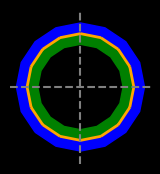

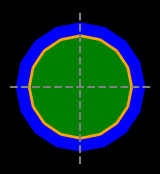

In [7]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Bordering Boxes
![Embedded Boxes](<../../Images/Boundaries\ExteriorBorders2D_SUP.png>)

In [8]:
def logical_bordering_boxes_example():
    '''bottom_box1 Equals bottom_box2
    bottom_box1 Borders top_box

    bottom_box2 Borders top_box is Logical
    '''
    slice_spacing = 0.5
    # bordering boxes
    bottom_box1 = make_box(roi_num=1, width=5, length=5, height=2,
                           offset_x=0, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    bottom_box2 = make_box(roi_num=2, width=5, length=5, height=2,
                           offset_x=0, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    top_box = make_box(roi_num=3, width=4, length=4, height=2,
                     offset_x=0, offset_y=0, offset_z=-2.5,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = bottom_box1 + bottom_box2 + top_box
    return slice_data


slice_data = logical_bordering_boxes_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Equal to
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Borders
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Borders
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Equal to'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Borders'},
 '(2, 3)': {'Is Logical:': True, 'Relationship:': 'Borders'}}


**Relationships (2,3) should be _Logical_**

#### Disjoint Cylinders
![Disjoint Cylinders](<../../Images/Logical/logical disjoint.png>)


In [9]:
def logical_disjoint_cylinders_example() -> list[ContourPoints]:
    '''cylinder_a Equals cylinder_b
    cylinder_a is Disjoint from cylinder_c,
    cylinder_b is Disjoint from cylinder_c.

    Verify that cylinder_a is Disjoint from cylinder_c is **Logical**.
    '''
    slice_spacing = 0.5
     # Centred cylinder
    cylinder_a = make_vertical_cylinder(roi_num=1, radius=2, length=8,
                                        offset_x=-2.5, offset_z=0,
                                        spacing=slice_spacing)
    # cylinder within primary
    cylinder_b = make_vertical_cylinder(roi_num=2, radius=2, length=8,
                                        offset_x=-2.5, offset_z=0,
                                        spacing=slice_spacing)
    # cylinder within primary
    cylinder_c = make_vertical_cylinder(roi_num=3, radius=2, length=8,
                                        offset_x=2.5, offset_z=0,
                                        spacing=slice_spacing)

    # combine the contours
    slice_data = cylinder_a + cylinder_b + cylinder_c
    return slice_data


slice_data = logical_disjoint_cylinders_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Equal to
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: is Disjoint from
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Equal to'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'is Disjoint from'},
 '(2, 3)': {'Is Logical:': True, 'Relationship:': 'is Disjoint from'}}


**Relationships (1,3) should be _Logical_**

#### Nested Cylinders
![Nested Cylinders](<../../Images/Logical/shelters_surrounds_contains.png>)

In [10]:
def shelters_surrounds_contains_example() -> list[ContourPoints]:
    '''Nested cylinders

    c_cylinder is a C-shaped cylinder made with a slot and hole.
    c_cylinder surrounds the hollow surrounded_cylinder.
    surrounded_cylinder surrounds the contained_cylinder, which is a solid cylinder.
    The surrounded_cylinder contains the contained_cylinder, which is a smaller solid cylinder.

    The logical relationships are as follows:
    A *Shelters* B,
    B *Surrounds* C, and
    C *Contains* D.

    A *Shelters* C is **Logical**,

    A *Shelters* D is **Logical**, and
    B *Surrounds* D is **Logical**.
    '''
    slice_spacing = 1
    # Outside Cylinder with slot and hole to create a C shape
    outer_circle_coords = circle_points(radius=8)
    circle_hole_coords = circle_points(radius=7)
    slot_coords = [(0,  4), (0, -4), (9, -4), (9, 4)]
    outer_circle = shapely.Polygon(outer_circle_coords)
    circle_hole = shapely.Polygon(circle_hole_coords)
    slot = shapely.Polygon(slot_coords)
    c_shape = outer_circle.difference(circle_hole.union(slot))
    c_cylinder = extrude_poly(c_shape, length=8, spacing=slice_spacing, roi_num=1)
    # Hollow cylinder with no slot
    closed_cylinder = make_vertical_cylinder(roi_num=2, radius=6, length=8,
                                            spacing=slice_spacing)
    cylinder_hole = make_vertical_cylinder(roi_num=2, radius=5, length=6,
                                            spacing=slice_spacing)
    # Solid cylinder inside the hollow cylinder
    surrounded_cylinder = make_vertical_cylinder(roi_num=3, radius=3, length=4,
                                                spacing=slice_spacing)
    # Solid cylinder contained within the surrounded cylinder
    contained_cylinder = make_vertical_cylinder(roi_num=4, radius=2, length=2,
                                                spacing=slice_spacing)
    slice_data = (c_cylinder +
                closed_cylinder + cylinder_hole +
                surrounded_cylinder +
                contained_cylinder
                )
    return slice_data

slice_data = shelters_surrounds_contains_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Adding structure Structure_4 (4)
INFO:structure_set:Calculating relationships for 4 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Shelters
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Shelters
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_4 (ROI 4) as: Shelters
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Surrounds
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_4 (ROI 4) as: Surrounds
INFO:structure_set:Calculated relationships between Structure_3 (ROI 3) and Structure_4 (ROI 4) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Shelters'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Shelters'},
 '(1, 4)': {'Is Logical:': True, 'Relationship:': 'Shelters'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Surrounds'},
 '(2, 4)': {'Is Logical:': True, 'Relationship:': 'Surrounds'},
 '(3, 4)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3), (1,4), (2,4), should all be _Logical_**

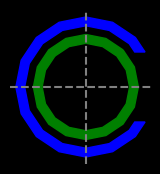

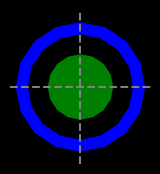

In [11]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Contains, Partitioned Boxes
![Nested partial Partitioned cubes](<../../Images/Logical/Contains,Partitions.png>)

In [12]:
def logical_contains_partitioned_example():
    '''cube10 Contains half_cube10
    half_cube10 is Partitioned by half_cube6

    cube10 Contains half_cube4 is Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=0, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    half_cube6 = make_box(roi_num=3, width=3, length=6, height=6,
                     offset_x=1, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = logical_contains_partitioned_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should be _Logical_**

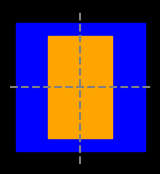

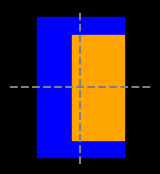

In [13]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Partitioned, Contains Boxes
![Nested partial Partitioned cubes](<../../Images/Logical/Partitions,Contains.png>)

In [14]:
def logical_partitions_contains_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 Contains half_cube6

    cube10 Contains half_cube4 is Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    half_cube6 = make_box(roi_num=3, width=3, length=6, height=6,
                     offset_x=2.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = logical_partitions_contains_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3) should be _Logical_**

## Not Logical Relationship Tests   

#### Disjoint Inner Cylinders
![Disjoint Inner Cylinders](<../../Images/Logical/Not Logical Disjoint Cylinders.png>)

In [15]:
def not_logical_disjoint_cylinders_example() -> list[ContourPoints]:
    '''primary_cylinder Contains contained_cylinder_B
    primary_cylinder Contains contained_cylinder_C,
    contained_cylinder_B is Disjoint from contained_cylinder_C.

    primary_cylinder Contains contained_cylinder_C is NOT Logical.
    '''
    slice_spacing = 0.5
     # Centred cylinder
    primary_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # cylinder within primary
    contained_cylinder_B = make_vertical_cylinder(roi_num=2, radius=2, length=6,
                                                  offset_x=2.5, offset_z=0,
                                                  spacing=slice_spacing)
    # cylinder within primary
    contained_cylinder_C = make_vertical_cylinder(roi_num=3, radius=2, length=6,
                                                  offset_x=-2.5, offset_z=0,
                                                  spacing=slice_spacing)

    # combine the contours
    slice_data = primary_cylinder + contained_cylinder_B + contained_cylinder_C
    return slice_data


slice_data = not_logical_disjoint_cylinders_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Disjoint from'}}


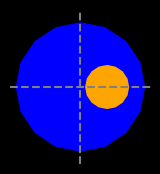

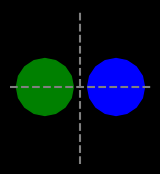

In [16]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

**Relationships (2,3) should NOT be _Logical_**

#### Bordered Boxes
![Bordered Boxes](<../../Images/Logical/borders 3 way.png>)

In [17]:
def not_logical_bordering_box_example():
    '''cube10 is Bordered by half_cube10
    half_cube10 is Bordered by half_cube4

    cube10 is Bordered by half_cube4 is NOT Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    half_cube10 = make_box(roi_num=1, width=8, length=4, height=8,
                           offset_x=0, offset_y=2, offset_z=0,
                           spacing=slice_spacing)

    left_cube4 = make_box(roi_num=2, width=4, height=8,
                          offset_x=-2, offset_y=-2, offset_z=0,
                          spacing=slice_spacing)

    right_cube4 = make_box(roi_num=3, width=4, height=8,
                          offset_x=2, offset_y=-2, offset_z=0,
                          spacing=slice_spacing)
    # combine the contours
    slice_data = half_cube10 + left_cube4 + right_cube4
    return slice_data


slice_data = not_logical_bordering_box_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Borders
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Borders
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Borders'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Borders'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Borders'}}


**Relationships (1,3) should NOT be _Logical_**

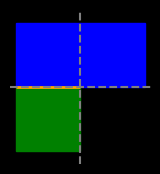

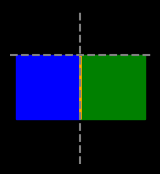

In [18]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Partitioned Boxes
![Partitioned Boxes](<../../Images/Logical/Nested Partitioned cubes.png>)

In [19]:
def not_logical_partitioned_box_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 is Partitioned by half_cube6

    cube10 is Partitioned by half_cube6 is Not Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)
    half_cube6 = make_box(roi_num=3, width=3, length=6,
                     offset_x=3.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = not_logical_partitioned_box_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should NOT be _Logical_**

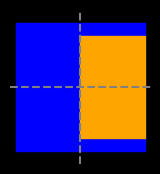

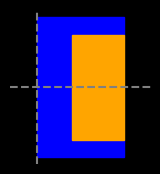

In [20]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Semi-Partitioned Boxes
![Semi-Partitioned Boxes](<../../Images/Logical/Nested partial Partitioned cubes.png>)


In [21]:
def not_logical_partitioned_contains_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 is Partitioned by half_cube4
    but cube10 is NOT Partitioned by half_cube4

    cube10 Contains half_cube4 is NOT Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)
    half_cube6 = make_box(roi_num=3, width=3, length=6,
                     offset_x=1.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = not_logical_partitioned_contains_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should NOT be _Logical_**

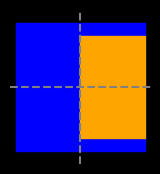

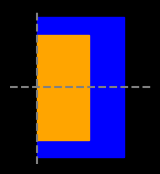

In [22]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)